In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(eps * mu)

# --- domínio ---
min_lambda = vp / 1e9  # comprimento de onda mínimo para 1 GHz = 3e-1 m
Nx = Ny = 50
dx = dy = 0.1 * min_lambda
dt = dx / (vp * np.sqrt(2))
Nt = 300

cx, cy = Nx // 2, Ny // 2

# --- campos ---
Ez = np.zeros((Nt, Nx, Ny))
Hx = np.zeros((Nt, Nx, Ny))
Hy = np.zeros((Nt, Nx, Ny))

for n in range(Nt-1):
    # --- fonte (pulso gaussiano no tempo) ---
    source_gaussiano = np.exp(-((n * dt - 1.8e-9)**2) / (0.6e-9)**2)

    # --- fonte (senoidal no tempo) ---
    frequency = 1e9  # 1 GHz
    source_senoidal = np.sin(2 * np.pi * frequency * n * dt)

    Ez[n, cx, cy] += source_gaussiano

    Hx[n+1, :, :-1] = Hx[n, :, :-1] - (dt/(mu*dy)) * (
        Ez[n, :, 1:] - Ez[n, :, :-1]
    )

    Hy[n+1, :-1, :] = Hy[n, :-1, :] + (dt/(mu*dx)) * (
        Ez[n, 1:, :] - Ez[n, :-1, :]
    )

    # --- Update E field (from H at time n+1) ---
    Ez[n+1, 1:-1, 1:-1] = Ez[n, 1:-1, 1:-1] + (dt/eps) * (
        (Hy[n+1, 1:-1, 1:-1] - Hy[n+1, :-2, 1:-1]) / dx -
        (Hx[n+1, 1:-1, 1:-1] - Hx[n+1, 1:-1, :-2]) / dy
    )

    # zero nas nas extremidades - PEC
    Ez[n+1, 1:-1, 0] = 0
    Ez[n+1, 1:-1, -1] = 0
    Ez[n+1, 0, 1:-1] = 0
    Ez[n+1, -1, 1:-1] = 0


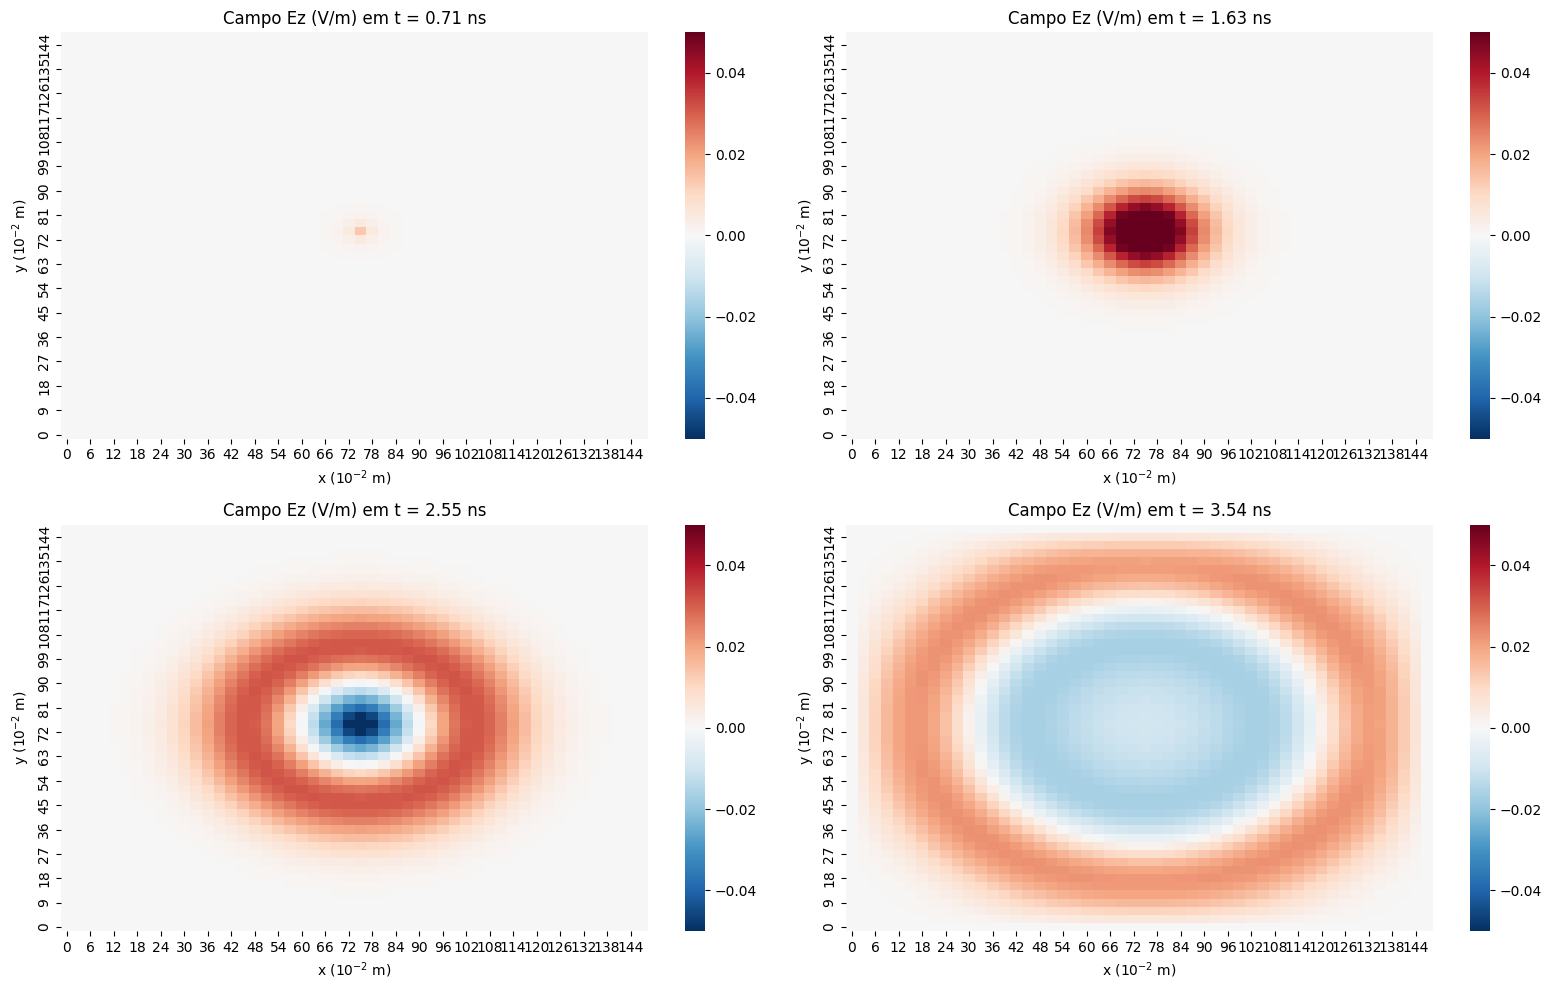

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
t_list = np.linspace(10, Nt//6, 4, dtype=int)  # 6 snapshots ao longo do tempo

for i, ax in enumerate(axes.flat):
    sns.heatmap(Ez[t_list[i], :, :], ax=ax, annot=False, cmap='RdBu_r',vmin=-0.05, vmax=0.05,center=0)
    ax.set_xlabel(r"x ($10^{-2}$ m)")
    ax.set_ylabel(r"y ($10^{-2}$ m)")
    ax.set_title(f"Campo Ez (V/m) em t = {t_list[i]*dt*1e9:.2f} ns")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 100:.0f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 100:.0f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()

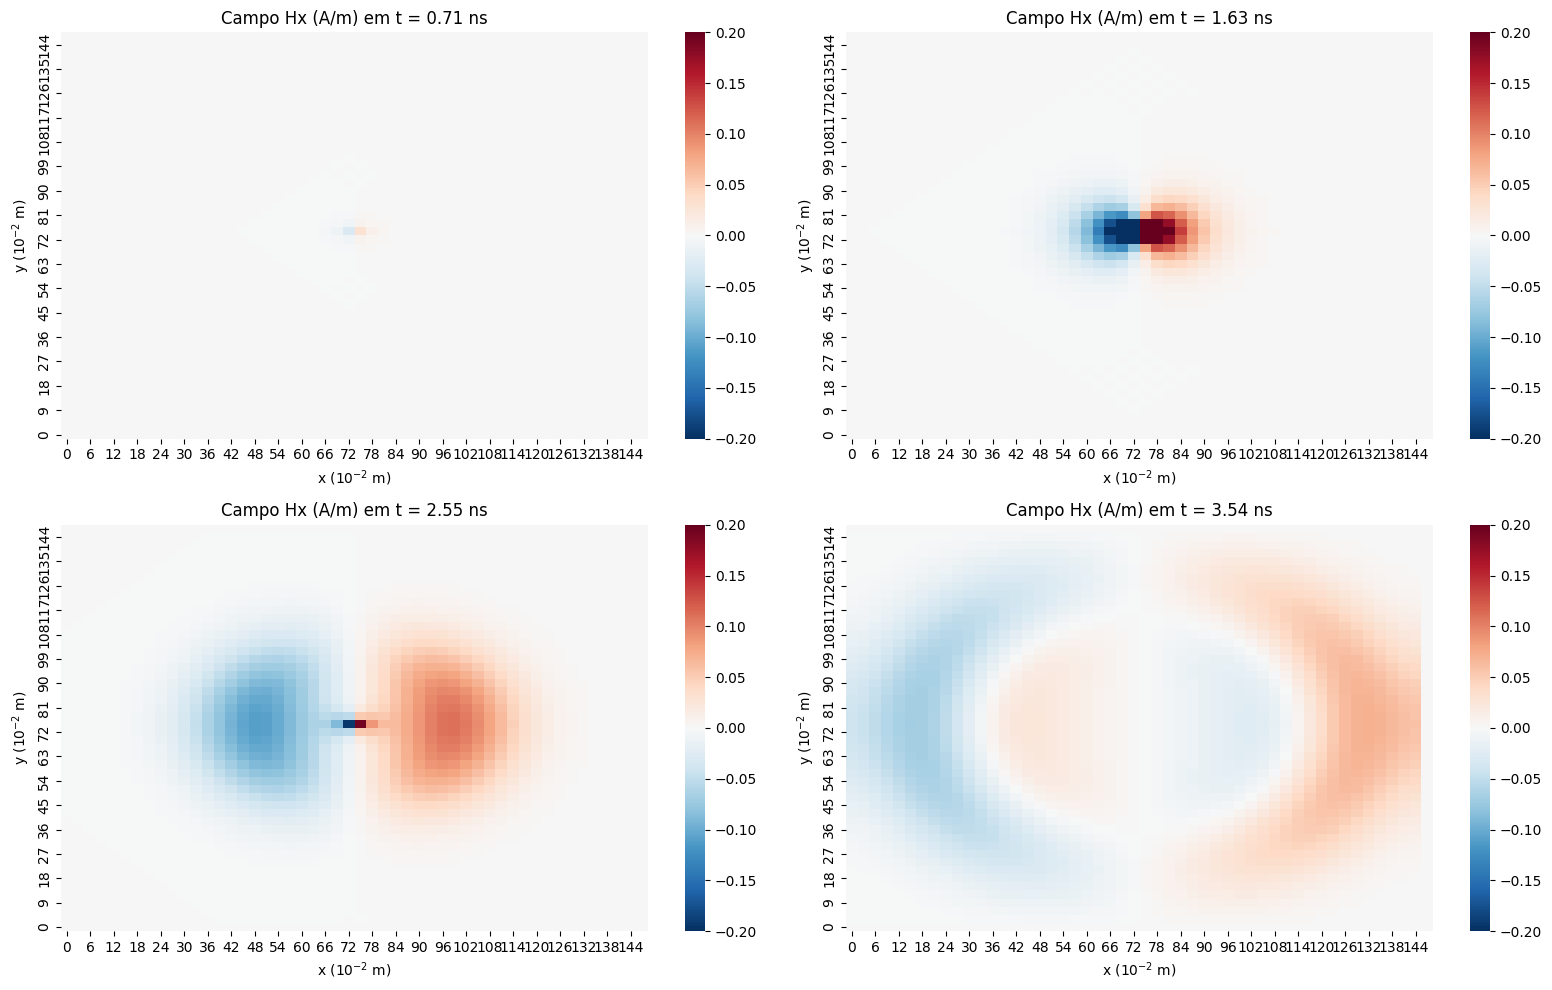

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
t_list = np.linspace(10, Nt//6, 4, dtype=int)  # 6 snapshots ao longo do tempo

for i, ax in enumerate(axes.flat):
    sns.heatmap(Hx[t_list[i], :, :] * 1e3, ax=ax, annot=False, cmap='RdBu_r',vmin=-0.2, vmax=0.2,center=0)
    ax.set_xlabel(r"x ($10^{-2}$ m)")
    ax.set_ylabel(r"y ($10^{-2}$ m)")
    ax.set_title(f"Campo Hx (A/m) em t = {t_list[i]*dt*1e9:.2f} ns")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 100:.0f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 100:.0f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [36]:
print(Hx)

[[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  ...
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]]

 [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  ...
  [ 0.00000000e+00  0.0

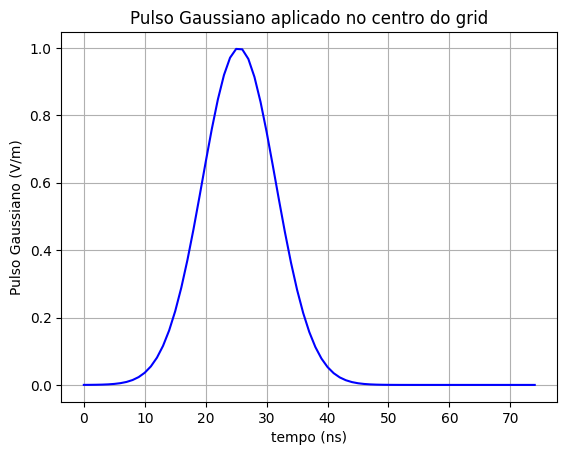

In [34]:
tgrid = np.arange(Nt//4) # Convert to nanoseconds
source_gaussiano = np.exp(-((tgrid * dt - 1.8e-9)**2) / (0.6e-9)**2)

# 2. Create a figure and axis
fig, ax = plt.subplots()

# 3. Plot the data
ax.plot(tgrid,source_gaussiano, label='Pulso Gaussiano (V/m)', color='blue')

# 4. Customize the plot
ax.set_title('Pulso Gaussiano aplicado no centro do grid')
ax.set_xlabel('tempo (ns)')
ax.set_ylabel('Pulso Gaussiano (V/m)')
ax.grid()

# 5. Display the result
plt.show()

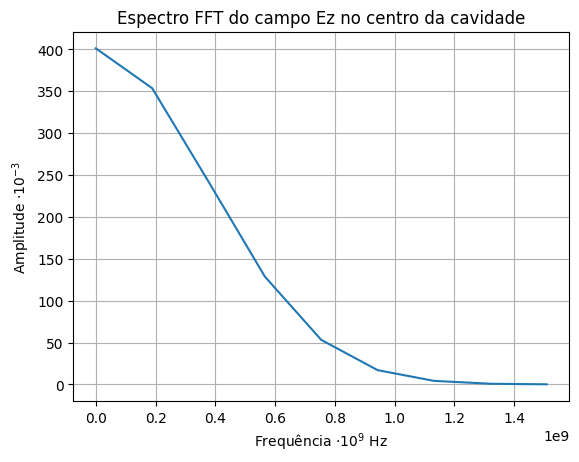

In [ ]:
# 2. Compute the FFT
yf = fft(source_gaussiano)
xf = fftfreq(len(source_gaussiano), dt)

# 3. Plot the results (Positive frequencies only)
plt.plot(xf[:len(source_gaussiano)//8], 1e3 * 2.0/len(source_gaussiano) * np.abs(yf[:len(source_gaussiano)//8]), color='blue')
plt.title("Espectro do pulso gaussiano aplicado no centro do grid")
plt.xlabel(r"Frequência $\cdot 10^{9}$ Hz")
plt.ylabel(r"Amplitude $\cdot 10^{-3}$")
plt.grid()
plt.show()